In [3]:
import pandas as pd
import numpy as np
import yfinance as yf
from dtaidistance import dtw
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import squareform
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# ============================================
# 1. DESCARGA Y PREPARACIÓN DE DATOS
# ============================================

# Los 7 magníficos
tickers = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'META', 'NVDA', 'TSLA']
nombres = {
    'AAPL': 'Apple',
    'MSFT': 'Microsoft', 
    'GOOGL': 'Alphabet (Google)',
    'AMZN': 'Amazon',
    'META': 'Meta',
    'NVDA': 'NVIDIA',
    'TSLA': 'Tesla'
}

# Descarga 2 años de datos
end_date = datetime.now()
start_date = end_date - timedelta(days=730)

print("Descargando datos de los 7 Magníficos...")
data = yf.download(tickers, start=start_date, end=end_date, progress=False)

# Extraemos Close y Volume
close_data = data['Close'].dropna()
volume_data = data['Volume'].dropna()

# También descargo SPY y QQQ para comparación
benchmarks = yf.download(['SPY', 'QQQ'], start=start_date, end=end_date, progress=False)['Close']

print(f"Datos descargados: {close_data.shape[0]} días de trading")
print(f"Tickers: {close_data.columns.tolist()}")

Descargando datos de los 7 Magníficos...
Datos descargados: 500 días de trading
Tickers: ['AAPL', 'AMZN', 'GOOGL', 'META', 'MSFT', 'NVDA', 'TSLA']


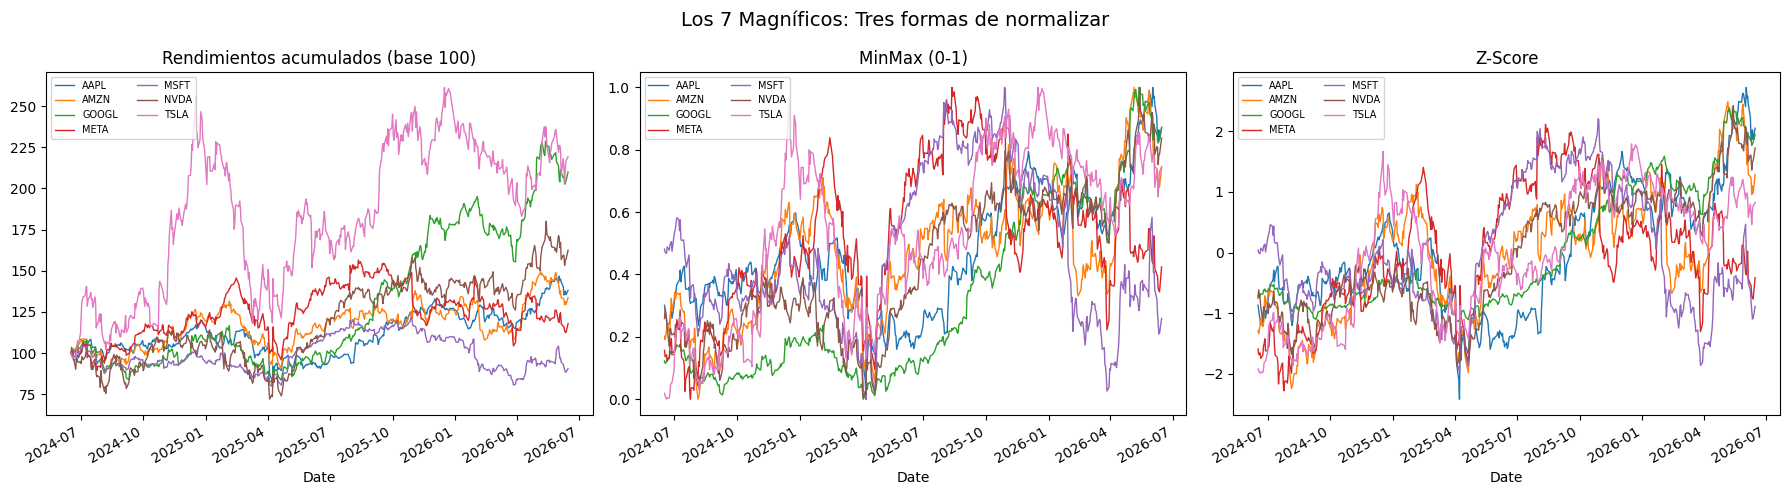

In [4]:
# ============================================
# 2. NORMALIZACIONES MÚLTIPLES
# ============================================

# Normalización 1: Rendimientos acumulados (base 100)
def to_cumulative_returns(prices):
    """Convierte precios a rendimientos acumulados base 100"""
    returns = prices.pct_change().fillna(0)
    return 100 * (1 + returns).cumprod()

cum_returns = to_cumulative_returns(close_data)

# Normalización 2: MinMax para DTW puro
def to_minmax(prices):
    """Escala 0-1 preservando la forma"""
    return (prices - prices.min()) / (prices.max() - prices.min())

minmax_data = close_data.apply(to_minmax)

# Normalización 3: Z-score para detectar divergencias
def to_zscore(prices):
    """Estandarización"""
    return (prices - prices.mean()) / prices.std()

zscore_data = close_data.apply(to_zscore)

# Visualiza las 3 normalizaciones
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

cum_returns.plot(ax=axes[0], linewidth=1)
axes[0].set_title('Rendimientos acumulados (base 100)')
axes[0].legend(loc='upper left', fontsize=7, ncol=2)

minmax_data.plot(ax=axes[1], linewidth=1)
axes[1].set_title('MinMax (0-1)')
axes[1].legend(loc='upper left', fontsize=7, ncol=2)

zscore_data.plot(ax=axes[2], linewidth=1)
axes[2].set_title('Z-Score')
axes[2].legend(loc='upper left', fontsize=7, ncol=2)

plt.suptitle('Los 7 Magníficos: Tres formas de normalizar', fontsize=14)
plt.tight_layout()
plt.show()

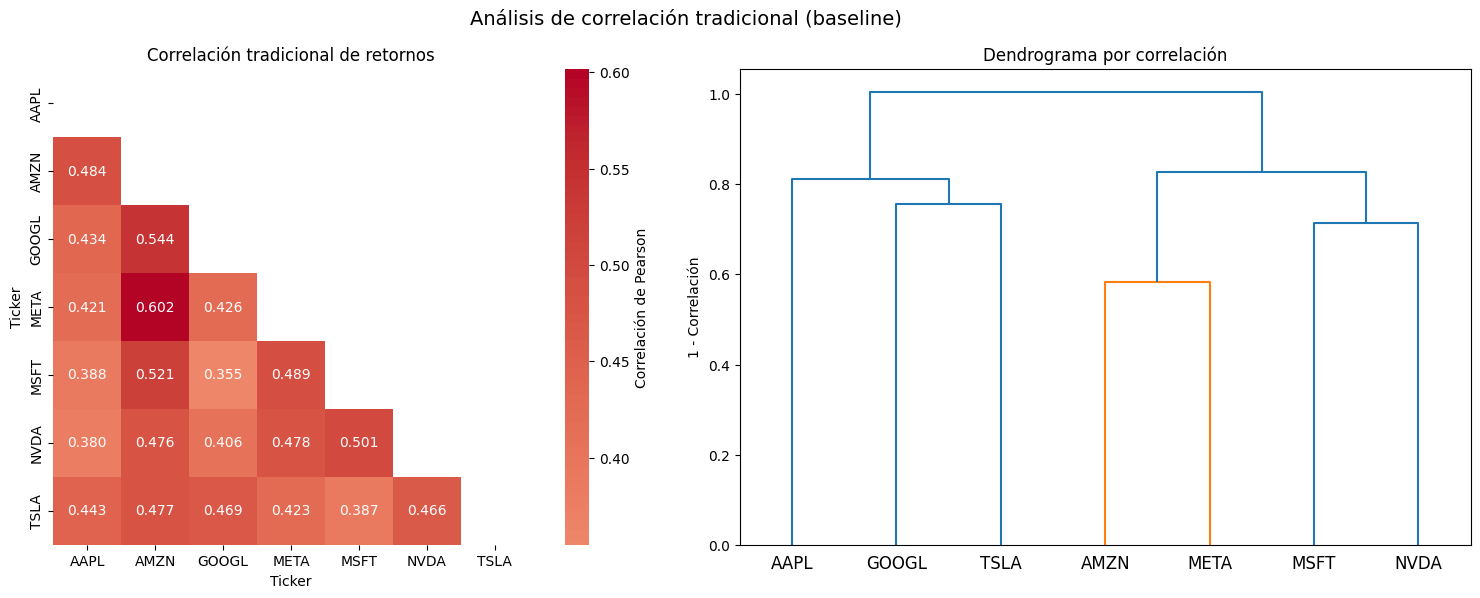

In [5]:
# ============================================
# 3. ANÁLISIS DE CORRELACIÓN TRADICIONAL (baseline)
# ============================================

# Matriz de correlación de Pearson
returns = close_data.pct_change().dropna()
correlation_matrix = returns.corr()

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap de correlación
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, annot=True, fmt='.3f', cmap='coolwarm', 
            center=0, mask=mask, square=True, ax=axes[0], 
            cbar_kws={'label': 'Correlación de Pearson'})
axes[0].set_title('Correlación tradicional de retornos')

# Clustering jerárquico por correlación
corr_linkage = linkage(1 - correlation_matrix, method='ward')
dendrogram(corr_linkage, labels=correlation_matrix.index, ax=axes[1])
axes[1].set_title('Dendrograma por correlación')
axes[1].set_ylabel('1 - Correlación')

plt.suptitle('Análisis de correlación tradicional (baseline)', fontsize=14)
plt.tight_layout()
plt.show()

In [6]:
# ============================================
# 4. MATRIZ DE DISTANCIAS DTW
# ============================================

def compute_dtw_matrix(data_normalized, max_length=None):
    """
    Calcula matriz de distancias DTW entre todas las acciones.
    data_normalized: DataFrame con columnas = tickers
    """
    tickers_list = data_normalized.columns.tolist()
    n = len(tickers_list)
    dist_matrix = np.zeros((n, n))
    
    print("Calculando distancias DTW...")
    for i in range(n):
        for j in range(i+1, n):
            s1 = data_normalized.iloc[:, i].dropna().values
            s2 = data_normalized.iloc[:, j].dropna().values
            
            # Si las series tienen diferente longitud, usar la mínima
            if max_length:
                s1 = s1[:max_length]
                s2 = s2[:max_length]
            
            dist = dtw.distance(s1, s2)
            dist_matrix[i, j] = dist
            dist_matrix[j, i] = dist
            
            print(f"  {tickers_list[i]:5s} vs {tickers_list[j]:5s}: {dist:.2f}")
    
    return pd.DataFrame(dist_matrix, index=tickers_list, columns=tickers_list)

# Calculamos DTW con datos MinMax (mejor para comparación de formas)
dtw_distances = compute_dtw_matrix(minmax_data)

# Normalizamos para comparar con correlación
# Convertimos distancia a "similitud DTW" (0-1, donde 1 = idéntico)
dtw_similarity = 1 / (1 + dtw_distances / dtw_distances.values.max())

Calculando distancias DTW...
  AAPL  vs AMZN : 1.34
  AAPL  vs GOOGL: 2.82
  AAPL  vs META : 2.87
  AAPL  vs MSFT : 3.63
  AAPL  vs NVDA : 1.31
  AAPL  vs TSLA : 2.03
  AMZN  vs GOOGL: 1.94
  AMZN  vs META : 2.12
  AMZN  vs MSFT : 2.99
  AMZN  vs NVDA : 1.79
  AMZN  vs TSLA : 1.49
  GOOGL vs META : 3.27
  GOOGL vs MSFT : 4.43
  GOOGL vs NVDA : 1.04
  GOOGL vs TSLA : 2.43
  META  vs MSFT : 2.25
  META  vs NVDA : 2.85
  META  vs TSLA : 1.82
  MSFT  vs NVDA : 3.52
  MSFT  vs TSLA : 3.94
  NVDA  vs TSLA : 2.37


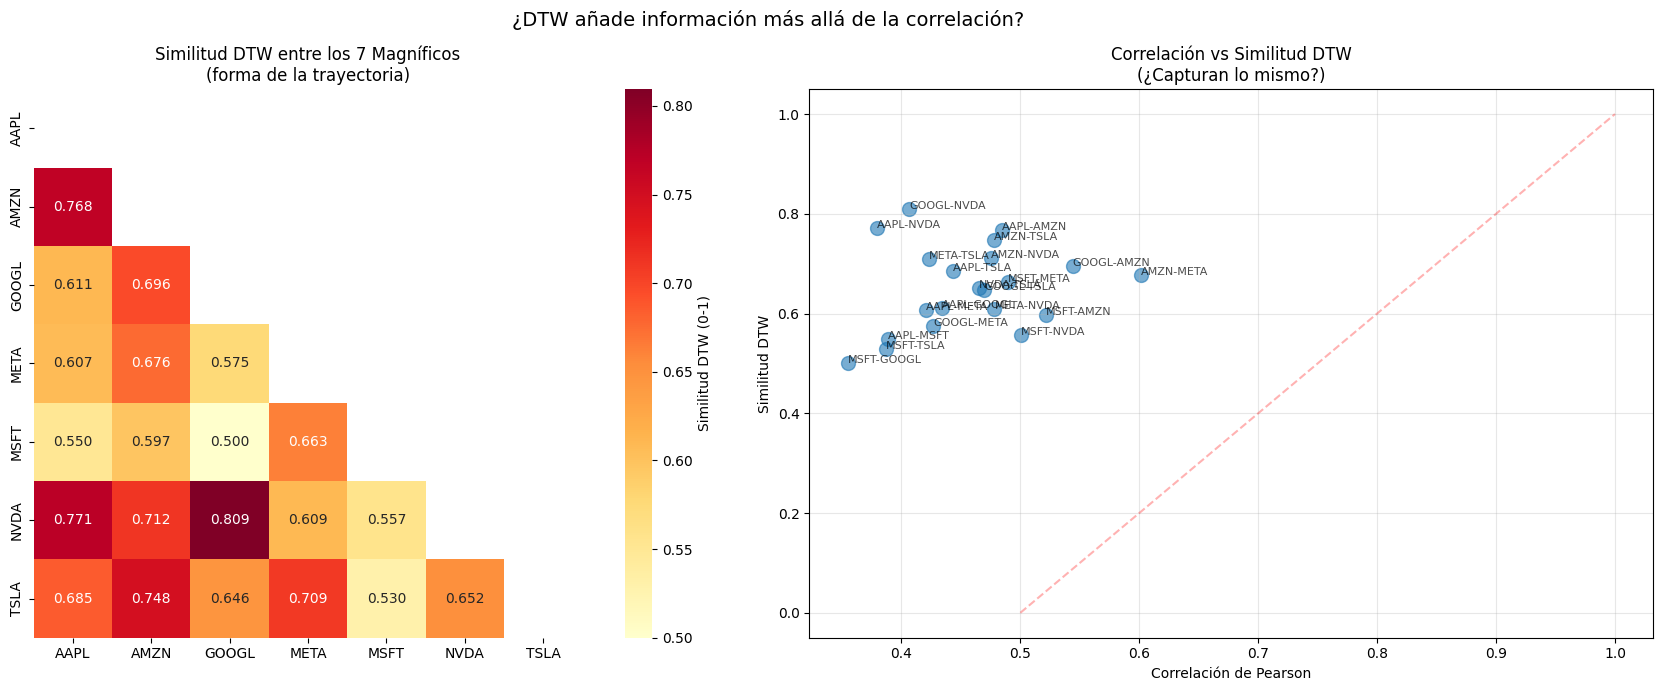

Pares donde DTW y correlación más difieren:
           Par  Correlación  Similitud_DTW  Diferencia
9    MSFT-NVDA     0.500734       0.557268    0.056534
15   AMZN-META     0.601628       0.676484    0.074856
7    MSFT-AMZN     0.521178       0.596915    0.075737
18   META-NVDA     0.478160       0.609060    0.130900
10   MSFT-TSLA     0.387333       0.529765    0.142432
6   MSFT-GOOGL     0.354768       0.500000    0.145232
12  GOOGL-META     0.426487       0.575408    0.148921
11  GOOGL-AMZN     0.543936       0.695883    0.151948
0    AAPL-MSFT     0.388361       0.549959    0.161598
8    MSFT-META     0.489491       0.662984    0.173493
1   AAPL-GOOGL     0.434371       0.610904    0.176533
14  GOOGL-TSLA     0.469352       0.646306    0.176954
3    AAPL-META     0.420571       0.606739    0.186167
20   NVDA-TSLA     0.465511       0.651820    0.186309
16   AMZN-NVDA     0.475626       0.711840    0.236214
5    AAPL-TSLA     0.443009       0.685480    0.242472
17   AMZN-TSLA     0.

In [7]:
# ============================================
# 5. COMPARACIÓN: CORRELACIÓN vs DTW
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Heatmap de DTW
mask = np.triu(np.ones_like(dtw_similarity, dtype=bool))
sns.heatmap(dtw_similarity, annot=True, fmt='.3f', cmap='YlOrRd', 
            mask=mask, square=True, ax=axes[0],
            cbar_kws={'label': 'Similitud DTW (0-1)'})
axes[0].set_title('Similitud DTW entre los 7 Magníficos\n(forma de la trayectoria)')

# Scatter: Correlación vs DTW
corr_pairs = []
dtw_pairs = []
labels = []

for i, ticker1 in enumerate(tickers):
    for j, ticker2 in enumerate(tickers):
        if i < j:
            corr_pairs.append(correlation_matrix.loc[ticker1, ticker2])
            dtw_pairs.append(dtw_similarity.loc[ticker1, ticker2])
            labels.append(f'{ticker1}-{ticker2}')

axes[1].scatter(corr_pairs, dtw_pairs, s=100, alpha=0.6)
for i, label in enumerate(labels):
    axes[1].annotate(label, (corr_pairs[i], dtw_pairs[i]), 
                    fontsize=8, alpha=0.7)
axes[1].set_xlabel('Correlación de Pearson')
axes[1].set_ylabel('Similitud DTW')
axes[1].set_title('Correlación vs Similitud DTW\n(¿Capturan lo mismo?)')
axes[1].grid(True, alpha=0.3)
axes[1].plot([0.5, 1], [0, 1], 'r--', alpha=0.3)  # línea de referencia

plt.suptitle('¿DTW añade información más allá de la correlación?', fontsize=14)
plt.tight_layout()
plt.show()

# Análisis: pares donde DTW y correlación difieren
comparison_df = pd.DataFrame({
    'Par': labels,
    'Correlación': corr_pairs,
    'Similitud_DTW': dtw_pairs,
    'Diferencia': np.array(dtw_pairs) - np.array(corr_pairs)
}).sort_values('Diferencia')

print("Pares donde DTW y correlación más difieren:")
print(comparison_df)

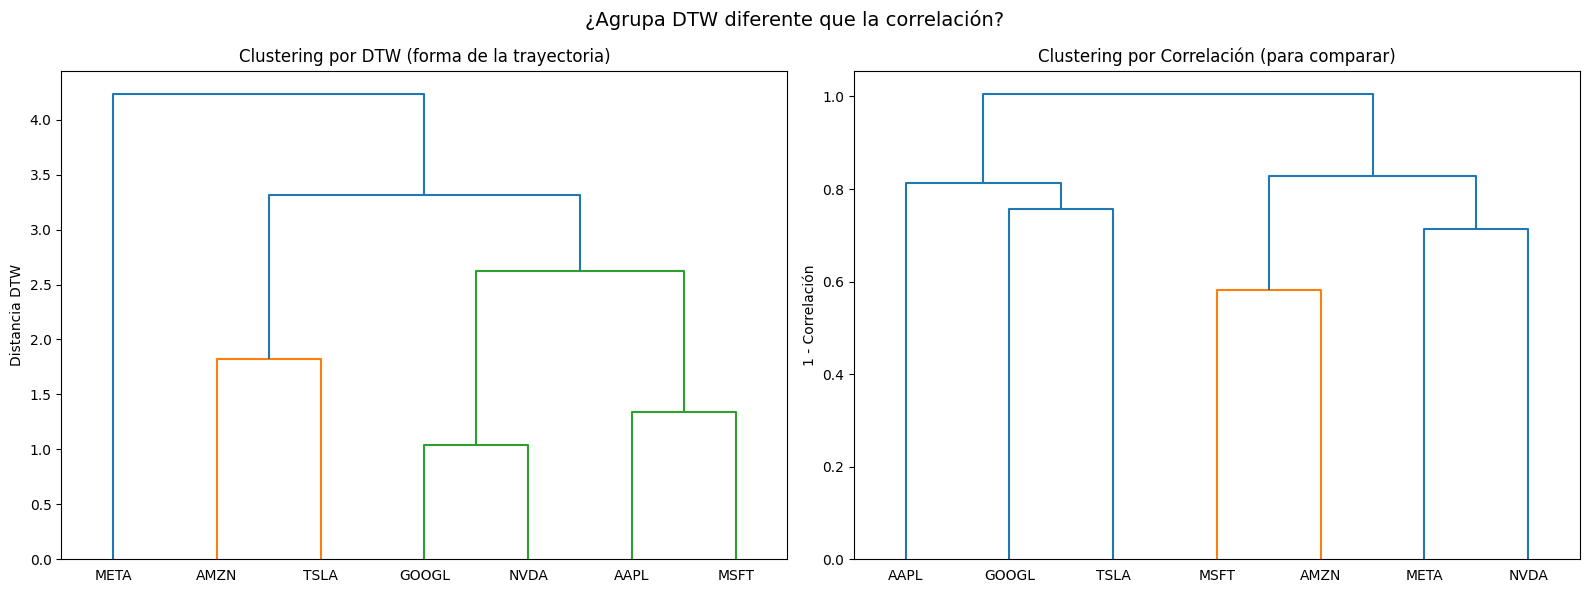


Comparación de clusters:
  Ticker  Cluster_DTW  Cluster_Correlación             Nombre
3   AMZN            1                    2             Amazon
6   TSLA            1                    1              Tesla
1   MSFT            2                    2          Microsoft
0   AAPL            2                    1              Apple
2  GOOGL            2                    1  Alphabet (Google)
5   NVDA            2                    3             NVIDIA
4   META            3                    3               Meta


In [8]:
# ============================================
# 6. CLUSTERING JERÁRQUICO CON DTW
# ============================================

# Dendrograma DTW
condensed_dist = squareform(dtw_distances.values)
dtw_linkage = linkage(condensed_dist, method='ward')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Dendrograma DTW
dendrogram(dtw_linkage, labels=tickers, ax=axes[0], leaf_font_size=10)
axes[0].set_title('Clustering por DTW (forma de la trayectoria)')
axes[0].set_ylabel('Distancia DTW')

# Comparación: dendrograma por correlación
dendrogram(corr_linkage, labels=tickers, ax=axes[1], leaf_font_size=10)
axes[1].set_title('Clustering por Correlación (para comparar)')
axes[1].set_ylabel('1 - Correlación')

plt.suptitle('¿Agrupa DTW diferente que la correlación?', fontsize=14)
plt.tight_layout()
plt.show()

# Extraer clusters
n_clusters = 3
dtw_clusters = fcluster(dtw_linkage, n_clusters, criterion='maxclust')
corr_clusters = fcluster(corr_linkage, n_clusters, criterion='maxclust')

cluster_comparison = pd.DataFrame({
    'Ticker': tickers,
    'Cluster_DTW': dtw_clusters,
    'Cluster_Correlación': corr_clusters,
    'Nombre': [nombres[t] for t in tickers]
})
print("\nComparación de clusters:")
print(cluster_comparison.sort_values('Cluster_DTW'))

In [9]:
# ============================================
# 7. ANÁLISIS LEAD-LAG ENTRE PARES
# ============================================

def find_lead_lag_dtw(stock1, stock2, data, max_lag=15):
    """
    Encuentra el lag óptimo donde la distancia DTW es mínima.
    Lag negativo: stock1 se adelanta a stock2
    Lag positivo: stock2 se adelanta a stock1
    """
    s1 = data[stock1].values
    s2 = data[stock2].values
    
    results = []
    for lag in range(-max_lag, max_lag + 1):
        if lag < 0:
            # stock1 está adelantada
            dist = dtw.distance(s1[-lag:], s2[:lag])
        elif lag > 0:
            # stock2 está adelantada
            dist = dtw.distance(s1[:-lag], s2[lag:])
        else:
            dist = dtw.distance(s1, s2)
        results.append({'Lag': lag, 'DTW_Distance': dist})
    
    results_df = pd.DataFrame(results)
    best_lag = results_df.loc[results_df['DTW_Distance'].idxmin(), 'Lag']
    
    return results_df, best_lag

# Analizar todos los pares
print("Analizando relaciones lead-lag entre los 7 Magníficos...\n")
lead_lag_results = []

for i, stock1 in enumerate(tickers):
    for j, stock2 in enumerate(tickers):
        if i < j:
            _, best_lag = find_lead_lag_dtw(stock1, stock2, minmax_data)
            
            if best_lag < 0:
                leader, follower = stock1, stock2
                days = abs(best_lag)
            elif best_lag > 0:
                leader, follower = stock2, stock1
                days = best_lag
            else:
                leader, follower = stock1, stock2
                days = 0
            
            lead_lag_results.append({
                'Par': f'{stock1}-{stock2}',
                'Líder': leader,
                'Seguidor': follower,
                'Días_Adelanto': days,
                'Lag_Óptimo': best_lag
            })

lead_lag_df = pd.DataFrame(lead_lag_results).sort_values('Días_Adelanto', ascending=False)
print(lead_lag_df.to_string())

Analizando relaciones lead-lag entre los 7 Magníficos...

           Par  Líder Seguidor  Días_Adelanto  Lag_Óptimo
3    AAPL-META   META     AAPL             15          15
12  GOOGL-META  GOOGL     META             15         -15
11  GOOGL-AMZN  GOOGL     AMZN             15         -15
8    MSFT-META   MSFT     META             15         -15
5    AAPL-TSLA   TSLA     AAPL             15          15
18   META-NVDA   NVDA     META             15          15
19   META-TSLA   TSLA     META             15          15
15   AMZN-META   AMZN     META             15         -15
14  GOOGL-TSLA  GOOGL     TSLA             15         -15
13  GOOGL-NVDA  GOOGL     NVDA             12         -12
20   NVDA-TSLA   TSLA     NVDA             11          11
6   MSFT-GOOGL  GOOGL     MSFT             10          10
0    AAPL-MSFT   AAPL     MSFT             10         -10
9    MSFT-NVDA   NVDA     MSFT             10          10
10   MSFT-TSLA   TSLA     MSFT             10          10
7    MSFT-AMZN

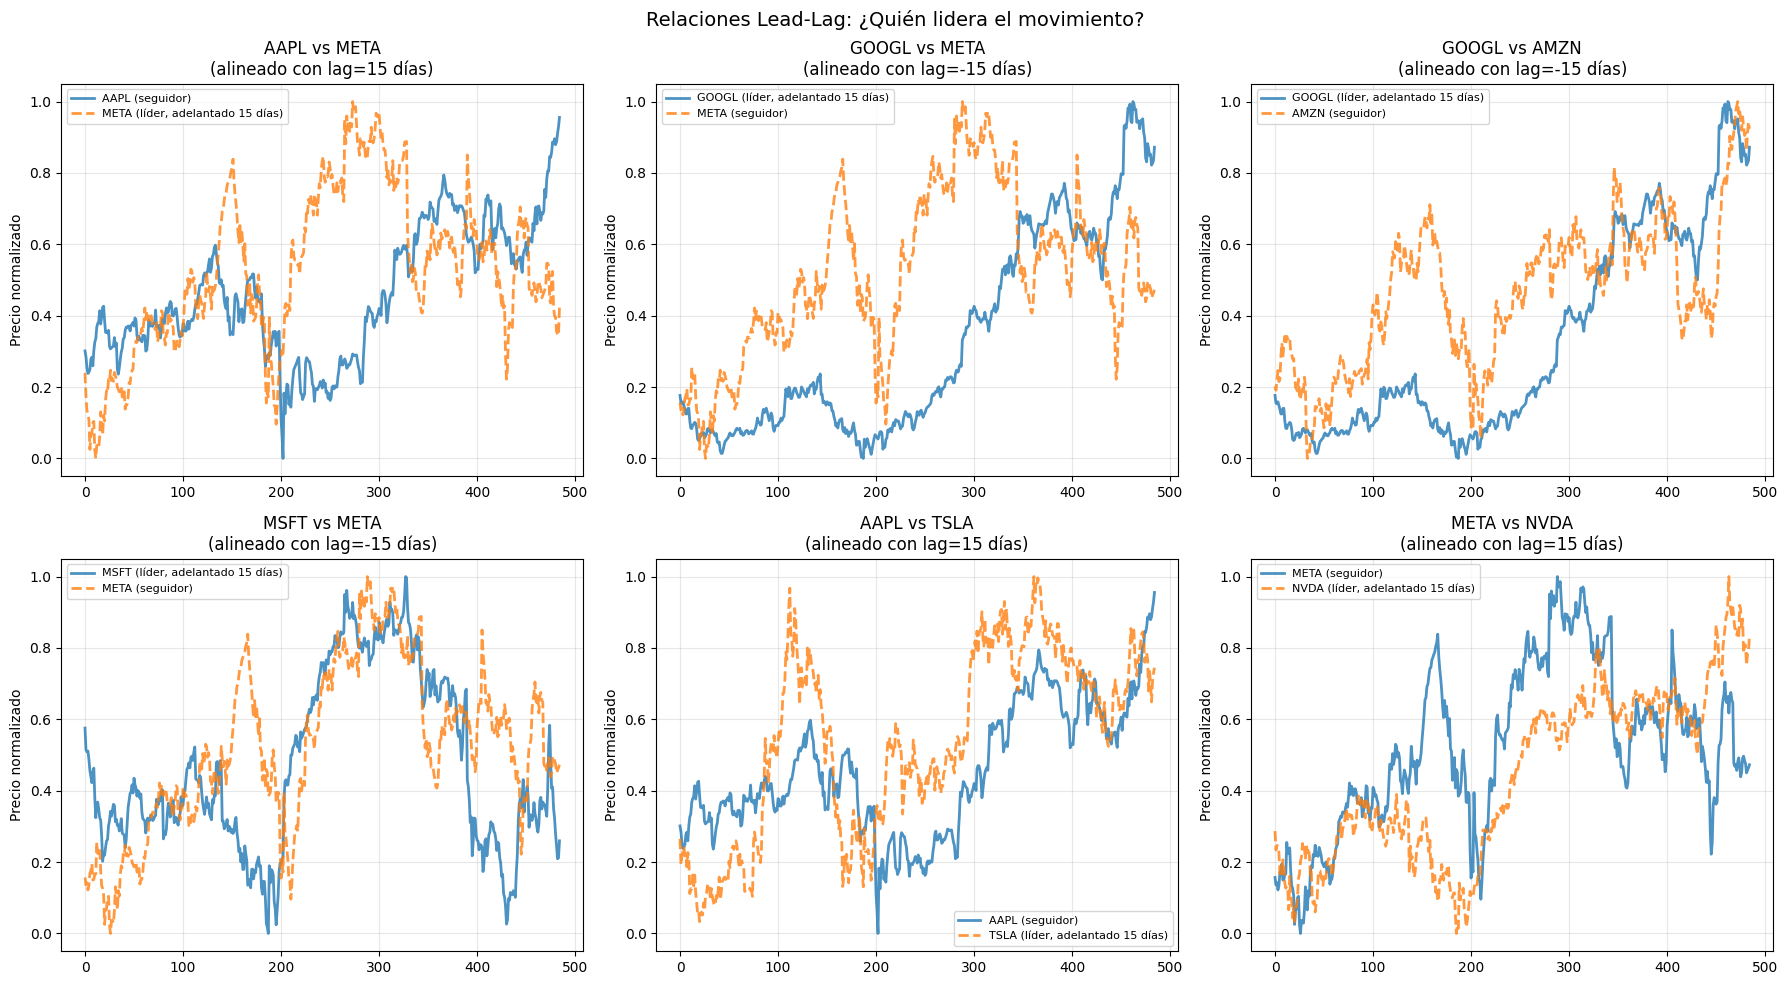

In [10]:
# ============================================
# 8. VISUALIZACIÓN DE LEAD-LAG (TOP PAIRES)
# ============================================

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flat

top_pairs = lead_lag_df.nlargest(6, 'Días_Adelanto')

for idx, (_, row) in enumerate(top_pairs.iterrows()):
    stock1, stock2 = row['Par'].split('-')
    lag = row['Lag_Óptimo']
    
    ax = axes[idx]
    
    # Alinear las series según el lag óptimo
    s1 = minmax_data[stock1].values
    s2 = minmax_data[stock2].values
    
    if lag < 0:
        s1_aligned = s1[-lag:]
        s2_aligned = s2[:lag]
        label1 = f'{stock1} (líder, adelantado {-lag} días)'
        label2 = f'{stock2} (seguidor)'
    elif lag > 0:
        s1_aligned = s1[:-lag]
        s2_aligned = s2[lag:]
        label1 = f'{stock1} (seguidor)'
        label2 = f'{stock2} (líder, adelantado {lag} días)'
    else:
        s1_aligned = s1
        s2_aligned = s2
        label1 = stock1
        label2 = stock2
    
    ax.plot(s1_aligned, label=label1, linewidth=2, alpha=0.8)
    ax.plot(s2_aligned, label=label2, linewidth=2, alpha=0.8, linestyle='--')
    ax.set_title(f'{stock1} vs {stock2}\n(alineado con lag={lag} días)')
    ax.legend(fontsize=8)
    ax.set_ylabel('Precio normalizado')
    ax.grid(True, alpha=0.3)

plt.suptitle('Relaciones Lead-Lag: ¿Quién lidera el movimiento?', fontsize=14)
plt.tight_layout()
plt.show()

TypeError: 'float' object is not subscriptable

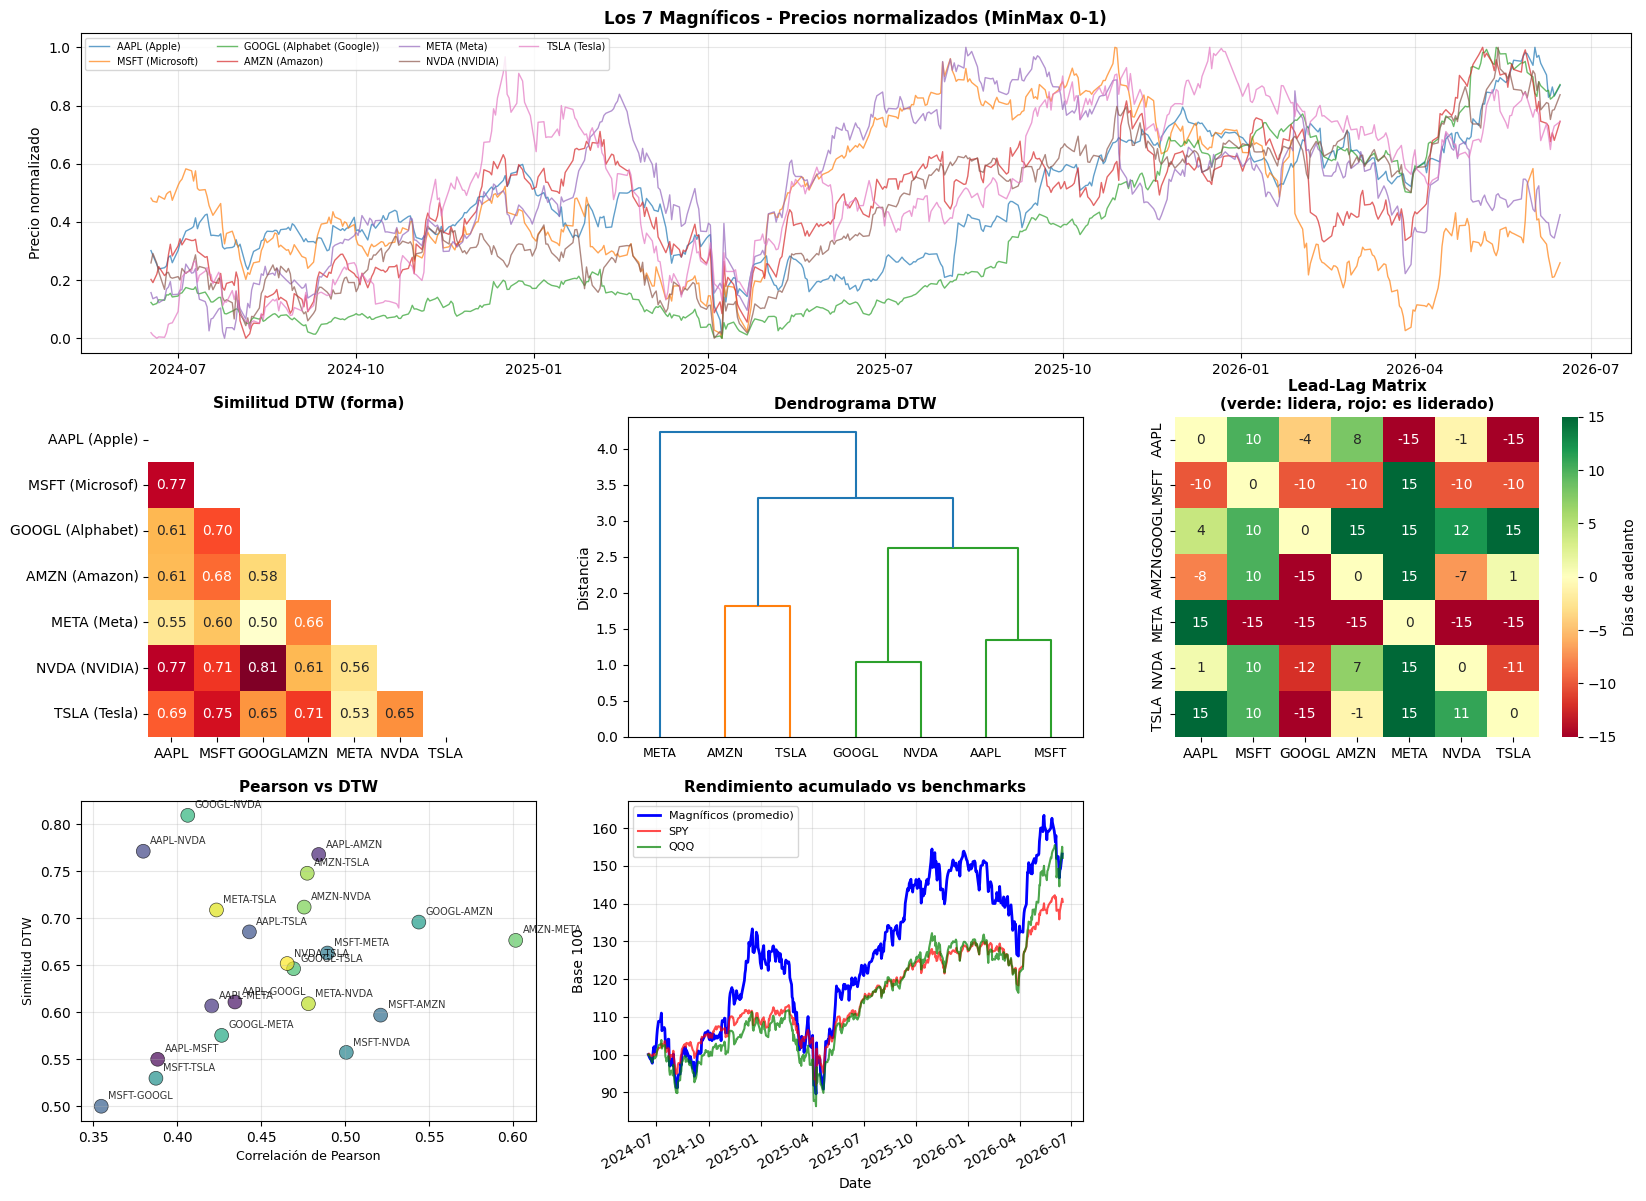

In [11]:
# ============================================
# 9. DASHBOARD FINAL: TODO EN UNO
# ============================================

fig = plt.figure(figsize=(20, 16))

# 1. Precios normalizados (arriba completo)
ax1 = plt.subplot(3, 3, (1, 3))
for ticker in tickers:
    ax1.plot(minmax_data.index, minmax_data[ticker], label=f'{ticker} ({nombres[ticker]})', 
             linewidth=1, alpha=0.7)
ax1.set_title('Los 7 Magníficos - Precios normalizados (MinMax 0-1)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Precio normalizado')
ax1.legend(loc='upper left', fontsize=7, ncol=4)
ax1.grid(True, alpha=0.3)

# 2. Mapa de calor DTW
ax2 = plt.subplot(3, 3, 4)
mask = np.triu(np.ones_like(dtw_similarity, dtype=bool))
sns.heatmap(dtw_similarity, annot=True, fmt='.2f', cmap='YlOrRd', 
            mask=mask, square=True, ax=ax2, cbar=False,
            xticklabels=[f'{t}' for t in tickers],
            yticklabels=[f'{t} ({nombres[t][:8]})' for t in tickers])
ax2.set_title('Similitud DTW (forma)', fontsize=11, fontweight='bold')

# 3. Dendrograma
ax3 = plt.subplot(3, 3, 5)
dendrogram(dtw_linkage, labels=[f'{t}' for t in tickers], ax=ax3, leaf_font_size=9)
ax3.set_title('Dendrograma DTW', fontsize=11, fontweight='bold')
ax3.set_ylabel('Distancia')

# 4. Lead-Lag matrix (quién lidera)
ax4 = plt.subplot(3, 3, 6)
lead_matrix = np.zeros((len(tickers), len(tickers)))
for _, row in lead_lag_df.iterrows():
    i = tickers.index(row['Par'].split('-')[0])
    j = tickers.index(row['Par'].split('-')[1])
    lag = row['Lag_Óptimo']
    if lag < 0:
        lead_matrix[i, j] = -lag  # stock i lidera
        lead_matrix[j, i] = lag
    elif lag > 0:
        lead_matrix[i, j] = -lag
        lead_matrix[j, i] = lag

sns.heatmap(lead_matrix, annot=True, fmt='.0f', cmap='RdYlGn', center=0,
            xticklabels=tickers, yticklabels=tickers, ax=ax4, cbar_kws={'label': 'Días de adelanto'})
ax4.set_title('Lead-Lag Matrix\n(verde: lidera, rojo: es liderado)', fontsize=11, fontweight='bold')

# 5. Scatter: Correlación vs DTW (todos los pares)
ax5 = plt.subplot(3, 3, 7)
scatter = ax5.scatter(corr_pairs, dtw_pairs, c=range(len(corr_pairs)), 
                      cmap='viridis', s=100, alpha=0.7, edgecolors='black', linewidth=0.5)
for i, label in enumerate(labels):
    ax5.annotate(label, (corr_pairs[i], dtw_pairs[i]), fontsize=7, alpha=0.8,
                xytext=(5, 5), textcoords='offset points')
ax5.set_xlabel('Correlación de Pearson', fontsize=9)
ax5.set_ylabel('Similitud DTW', fontsize=9)
ax5.set_title('Pearson vs DTW', fontsize=11, fontweight='bold')
ax5.grid(True, alpha=0.3)

# 6. Rendimientos acumulados con SPY/QQQ
ax6 = plt.subplot(3, 3, 8)
cum_returns_mean = cum_returns.mean(axis=1)
cum_returns_mean.plot(ax=ax6, label='Magníficos (promedio)', linewidth=2, color='blue')
to_cumulative_returns(benchmarks['SPY']).plot(ax=ax6, label='SPY', linewidth=1.5, color='red', alpha=0.7)
to_cumulative_returns(benchmarks['QQQ']).plot(ax=ax6, label='QQQ', linewidth=1.5, color='green', alpha=0.7)
ax6.set_title('Rendimiento acumulado vs benchmarks', fontsize=11, fontweight='bold')
ax6.set_ylabel('Base 100')
ax6.legend(fontsize=8)
ax6.grid(True, alpha=0.3)

# 7. Tabla resumen
ax7 = plt.subplot(3, 3, 9)
ax7.axis('off')
summary_text = "RESUMEN DE INSIGHTS:\n\n"
summary_text += "🔹 Pares más similares (DTW):\n"
for _, row in dtw_similarity.unstack().sort_values(ascending=False).head(3).items():
    if row > 0:
        summary_text += f"  {row[0]}-{row[1]}: {row[2]:.2f}\n"

summary_text += "\n🔹 Relaciones líder-seguidor:\n"
for _, row in lead_lag_df.nlargest(3, 'Días_Adelanto').iterrows():
    summary_text += f"  {row['Líder']} → {row['Seguidor']}: {row['Días_Adelanto']} días\n"

summary_text += "\n🔹 Clusters por forma:\n"
for cluster in range(1, n_clusters+1):
    members = cluster_comparison[cluster_comparison['Cluster_DTW'] == cluster]['Ticker'].tolist()
    summary_text += f"  Grupo {cluster}: {', '.join(members)}\n"

ax7.text(0.1, 0.5, summary_text, fontsize=9, verticalalignment='center', 
         fontfamily='monospace', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle('ANÁLISIS COMPLETO DE LOS 7 MAGNÍFICOS USANDO DTW\n', 
             fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

In [12]:
# ============================================
# 10. APLICACIONES PRÁCTICAS
# ============================================

print("\n" + "="*60)
print("APLICACIONES PRÁCTICAS PARA TRADING")
print("="*60)

# A) Pairs Trading Potencial
print("\n📊 POTENCIALES PARES PARA TRADING (alta similitud DTW):")
pairs_for_trading = []
for i in range(len(tickers)):
    for j in range(i+1, len(tickers)):
        sim = dtw_similarity.iloc[i, j]
        corr = correlation_matrix.iloc[i, j]
        if sim > 0.7:  # Alta similitud
            pairs_for_trading.append({
                'Par': f'{tickers[i]}-{tickers[j]}',
                'Similitud_DTW': sim,
                'Correlación': corr,
                'Potencial': 'Alto' if sim > 0.8 else 'Medio'
            })

pairs_df = pd.DataFrame(pairs_for_trading).sort_values('Similitud_DTW', ascending=False)
print(pairs_df.to_string())

# B) Estrategia de Momentum Cruzado (usando lead-lag)
print("\n🚀 ESTRATEGIA DE MOMENTUM CRUZADO:")
print("Si NVDA sube, comprar MSFT 3 días después (si MSFT aún no ha subido)")
for _, row in lead_lag_df.nlargest(3, 'Días_Adelanto').iterrows():
    print(f"  {row['Líder']} sube → {row['Días_Adelanto']} días después → {row['Seguidor']} debería seguir")

# C) Diversificación Real
print("\n🛡️ DIVERSIFICACIÓN REAL:")
print("Pares con BAJA similitud DTW (mejor diversificación):")
low_sim = dtw_similarity.unstack().sort_values()
for (s1, s2), sim in low_sim.head(3).items():
    if s1 != s2:
        print(f"  {s1} y {s2}: Similitud DTW = {sim:.3f} (buena diversificación)")

# D) Sustitución de Activos
print("\n🔄 SUSTITUCIÓN DE ACTIVOS:")
print("Si no puedes tradear SPY, usa el magnífico más similar:")
for ticker in tickers:
    dtw_to_spy = compute_dtw_matrix(pd.concat([minmax_data[ticker], 
                                               to_minmax(benchmarks['SPY'])], axis=1))
    sim = 1 / (1 + dtw_to_spy.iloc[0,1] / dtw_distances.values.max())
    print(f"  {ticker} como sustituto de SPY: Similitud = {sim:.3f}")


APLICACIONES PRÁCTICAS PARA TRADING

📊 POTENCIALES PARES PARA TRADING (alta similitud DTW):
          Par  Similitud_DTW  Correlación Potencial
4  GOOGL-NVDA       0.809466     0.406295      Alto
1   AAPL-NVDA       0.771259     0.379793     Medio
0   AAPL-MSFT       0.767841     0.484299     Medio
3   MSFT-TSLA       0.747851     0.477470     Medio
2   MSFT-NVDA       0.711840     0.475626     Medio
5   AMZN-TSLA       0.708790     0.423398     Medio

🚀 ESTRATEGIA DE MOMENTUM CRUZADO:
Si NVDA sube, comprar MSFT 3 días después (si MSFT aún no ha subido)
  META sube → 15 días después → AAPL debería seguir
  GOOGL sube → 15 días después → META debería seguir
  GOOGL sube → 15 días después → AMZN debería seguir

🛡️ DIVERSIFICACIÓN REAL:
Pares con BAJA similitud DTW (mejor diversificación):
  MSFT y GOOGL: Similitud DTW = 0.500 (buena diversificación)
  GOOGL y MSFT: Similitud DTW = 0.500 (buena diversificación)
  TSLA y MSFT: Similitud DTW = 0.530 (buena diversificación)

🔄 SUSTITUCIÓN D